In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf

##### Data Exploration and Understanding

In [2]:
file_path ='/Users/shubhangimore/Stock_Price_Prediction/Dataset/portfolio_data.csv'
data= pd.read_csv(file_path)
data

,Date,AMZN,DPZ,BTC,NFLX
0,5/1/2013,248.229996,51.190983,106.250000,30.415714
1,5/2/2013,252.550003,51.987320,98.099998,30.641428
2,5/3/2013,258.049988,52.446388,112.900002,30.492857
3,5/6/2013,255.720001,53.205257,109.599998,30.098572
4,5/7/2013,257.730011,54.151505,113.199997,29.464285
...,...,...,...,...,...
1515,5/8/2019,1917.770020,283.149994,6171.959961,364.369995
1516,5/9/2019,1899.869995,282.160004,6358.290039,362.750000
1517,5/10/2019,1889.979980,278.369995,7191.359863,361.040009
1518,5/13/2019,1822.680054,273.880005,7980.129883,345.260010


In [3]:
data.shape

(1520, 5)

In [4]:
data.dtypes

Date     object
AMZN    float64
DPZ     float64
BTC     float64
NFLX    float64
dtype: object

In [5]:
data.describe

<bound method NDFrame.describe of            Date         AMZN         DPZ          BTC        NFLX
0      5/1/2013   248.229996   51.190983   106.250000   30.415714
1      5/2/2013   252.550003   51.987320    98.099998   30.641428
2      5/3/2013   258.049988   52.446388   112.900002   30.492857
3      5/6/2013   255.720001   53.205257   109.599998   30.098572
4      5/7/2013   257.730011   54.151505   113.199997   29.464285
...         ...          ...         ...          ...         ...
1515   5/8/2019  1917.770020  283.149994  6171.959961  364.369995
1516   5/9/2019  1899.869995  282.160004  6358.290039  362.750000
1517  5/10/2019  1889.979980  278.369995  7191.359863  361.040009
1518  5/13/2019  1822.680054  273.880005  7980.129883  345.260010
1519  5/14/2019  1840.119995  272.859985  8183.830078  345.609985

[1520 rows x 5 columns]>

In [6]:
data.isnull()

,Date,AMZN,DPZ,BTC,NFLX
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
1515,False,False,False,False,False
1516,False,False,False,False,False
1517,False,False,False,False,False
1518,False,False,False,False,False


In [7]:
data.head()

,Date,AMZN,DPZ,BTC,NFLX
0,5/1/2013,248.229996,51.190983,106.250000,30.415714
1,5/2/2013,252.550003,51.987320,98.099998,30.641428
2,5/3/2013,258.049988,52.446388,112.900002,30.492857
3,5/6/2013,255.720001,53.205257,109.599998,30.098572
4,5/7/2013,257.730011,54.151505,113.199997,29.464285


In [8]:
data.tail()

,Date,AMZN,DPZ,BTC,NFLX
1515,5/8/2019,1917.770020,283.149994,6171.959961,364.369995
1516,5/9/2019,1899.869995,282.160004,6358.290039,362.750000
1517,5/10/2019,1889.979980,278.369995,7191.359863,361.040009
1518,5/13/2019,1822.680054,273.880005,7980.129883,345.260010
1519,5/14/2019,1840.119995,272.859985,8183.830078,345.609985


In [9]:
#numerical columns
num_data=data.select_dtypes(include=['int64','float64'])
num_data.columns

Index(['AMZN', 'DPZ', 'BTC', 'NFLX'], dtype='object')

In [10]:
#categorical columns
cat_data= data.select_dtypes(include=['object'])
cat_data.columns

Index(['Date'], dtype='object')

In [11]:
#unique values
for x in cat_data:
  print(x)
  print("unique_values",data[x].unique())
  print("value_count",data[x].value_counts())
  print('--------------------------')

Date
unique_values ['5/1/2013' '5/2/2013' '5/3/2013' ... '5/10/2019' '5/13/2019' '5/14/2019']
value_count Date
5/1/2013     1
5/4/2017     1
5/17/2017    1
5/16/2017    1
5/15/2017    1
            ..
5/1/2015     1
4/30/2015    1
4/29/2015    1
4/28/2015    1
5/14/2019    1
Name: count, Length: 1520, dtype: int64
--------------------------


In [12]:
data.columns = data.columns.str.strip()  # Remove leading/trailing spaces
data.columns = data.columns.str.lower()  # Convert to lowercase for uniformity
print(data.columns)


Index(['date', 'amzn', 'dpz', 'btc', 'nflx'], dtype='object')


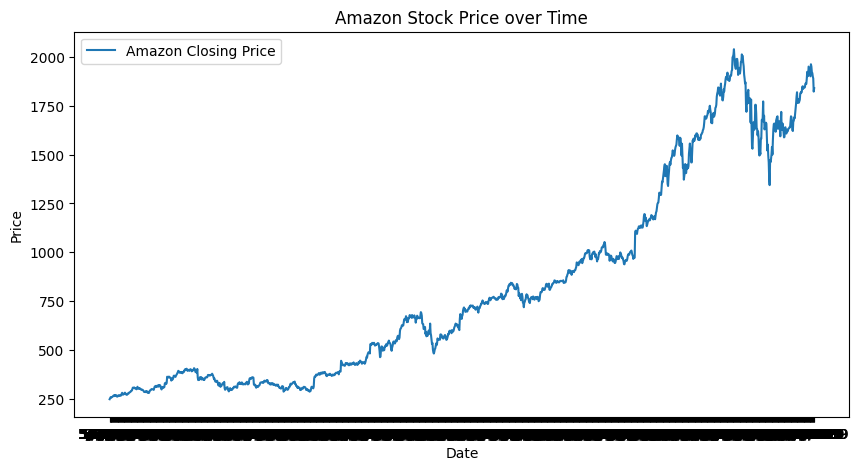

In [13]:
plt.figure(figsize=(10,5))
plt.plot(data['date'], data['amzn'], label='Amazon Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Amazon Stock Price over Time')
plt.legend()
plt.show()


In [14]:
data['date'] = pd.to_datetime(data['date'])

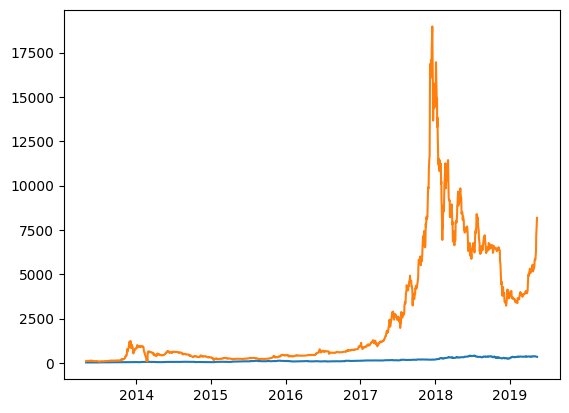

In [35]:
plt.plot(data['date'], data['nflx'], label='Netflix Closing Price')
# Or for Bitcoin:
plt.plot(data['date'], data['btc'], label='Bitcoin Price')


#### Feature Engineering
Lag Features: Create lag features to represent the previous day’s closing price, or a series of past prices, as they often have a strong influence on the next day’s price.

In [16]:
# Create lag features for Amazon stock price
data['lag_1'] = data['amzn'].shift(1)  # Previous day Amazon closing price
data['lag_2'] = data['amzn'].shift(2)  # 2 days ago Amazon closing price


Technical Indicators: Moving Averages (SMA, EMA):
Create simple moving averages (e.g., 7-day, 14-day) and exponential moving averages.

In [19]:
print(data.columns)

Index(['date', 'amzn', 'dpz', 'btc', 'nflx', 'lag_1', 'lag_2'], dtype='object')


In [20]:
# Calculate Simple Moving Averages (SMA) and Exponential Moving Averages (EMA) for Amazon ('amzn')
data['SMA_7'] = data['amzn'].rolling(window=7).mean()
data['SMA_14'] = data['amzn'].rolling(window=14).mean()
data['EMA_7'] = data['amzn'].ewm(span=7, adjust=False).mean()

# Check if the moving averages are calculated correctly
print(data[['amzn', 'SMA_7', 'SMA_14', 'EMA_7']].head())


         amzn  SMA_7  SMA_14       EMA_7
0  248.229996    NaN     NaN  248.229996
1  252.550003    NaN     NaN  249.309998
2  258.049988    NaN     NaN  251.494995
3  255.720001    NaN     NaN  252.551247
4  257.730011    NaN     NaN  253.845938


In [23]:
data.fillna(method='ffill', inplace=True)  # Forward fill
# OR
data.fillna(method='bfill', inplace=True)  # Backward fill


In [24]:
data = data[14:]  # This will keep rows from index 14 onward

In [25]:
# Check the last few rows to verify moving averages
print(data[['amzn', 'SMA_7', 'SMA_14', 'EMA_7']].tail())

             amzn        SMA_7       SMA_14        EMA_7
1515  1917.770020  1927.234288  1918.319293  1925.645772
1516  1899.869995  1923.427142  1921.046439  1919.201828
1517  1889.979980  1920.349993  1921.237148  1911.896366
1518  1822.680054  1909.187151  1914.016436  1889.592288
1519  1840.119995  1891.710013  1909.614293  1877.224215


In [21]:
# Calculate SMAs and EMAs for Domino's Pizza ('dpz')
data['SMA_7_DPZ'] = data['dpz'].rolling(window=7).mean()
data['SMA_14_DPZ'] = data['dpz'].rolling(window=14).mean()
data['EMA_7_DPZ'] = data['dpz'].ewm(span=7, adjust=False).mean()

# Check the values
print(data[['dpz', 'SMA_7_DPZ', 'SMA_14_DPZ', 'EMA_7_DPZ']].head())


         dpz  SMA_7_DPZ  SMA_14_DPZ  EMA_7_DPZ
0  51.190983        NaN         NaN  51.190983
1  51.987320        NaN         NaN  51.390067
2  52.446388        NaN         NaN  51.654147
3  53.205257        NaN         NaN  52.041925
4  54.151505        NaN         NaN  52.569320


In [27]:
data.fillna(method='ffill', inplace=True)  # Forward fill
data_filled = data.fillna(method='ffill')

In [28]:
# Check the cleaned or filled data
print(data_filled[['dpz', 'SMA_7_DPZ', 'SMA_14_DPZ', 'EMA_7_DPZ']].head(15))

          dpz  SMA_7_DPZ  SMA_14_DPZ  EMA_7_DPZ
14  53.355167  53.949409   53.728573  53.641893
15  53.036613  53.729911   53.803522  53.490573
16  55.472504  53.758018   54.019673  53.986056
17  55.013439  53.902565   54.148829  54.242901
18  55.894104  54.263933   54.273301  54.655702
19  55.538086  54.492799   54.355612  54.876298
20  56.015888  54.903686   54.498151  55.161196
21  55.528717  55.214193   54.581801  55.253076
22  55.950310  55.630435   54.680173  55.427384
23  56.381283  55.760261   54.759139  55.665859
24  54.666786  55.710739   54.806652  55.416091
25  55.697353  55.682632   54.973282  55.486406
26  56.709190  55.849932   55.171366  55.792102
27  56.887188  55.974404   55.439045  56.065874
28  56.025265  56.045339   55.629766  56.055722


Relative Strength Index (RSI):
RSI measures the speed and change of price movements. It’s a momentum indicator.

The Relative Strength Index (RSI) is indeed a popular momentum oscillator that measures the speed and change of price movements. It ranges from 0 to 100 and is typically used to identify overbought or oversold conditions in a stock or other asset. An RSI above 70 often indicates that an asset is overbought, while an RSI below 30 may indicate that it is oversold.

Calculating the RSI
The RSI is calculated using the following steps:

Calculate the Price Changes: Determine the daily price changes by subtracting the previous day's closing price from the current day's closing price.

Separate Gains and Losses:

If the price change is positive, it's a gain; if it's negative, it's a loss.
Create two separate series for gains and losses.
Calculate the Average Gain and Average Loss:

Typically, the average gain and average loss are calculated over a 14-day period.
Calculate the Relative Strength (RS):

RS = Average Gain / Average Loss
Calculate the RSI:

RSI = 100 - (100 / (1 + RS))

In [34]:
def calculate_rsi(data, window=14):
    # Calculate price changes
    delta = data['dpz'].diff()
    
    # Separate gains and losses
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()

    # Calculate RS
    rs = gain / loss
    
    # Calculate RSI
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

# Add RSI to the DataFrame
data['RSI'] = calculate_rsi(data)

# Check the results
print(data[['dpz', 'RSI']].head(20))  # Display the first 20 rows

          dpz        RSI
14  53.355167        NaN
15  53.036613        NaN
16  55.472504        NaN
17  55.013439        NaN
18  55.894104        NaN
19  55.538086        NaN
20  56.015888        NaN
21  55.528717        NaN
22  55.950310        NaN
23  56.381283        NaN
24  54.666786        NaN
25  55.697353        NaN
26  56.709190        NaN
27  56.887188  67.309364
28  56.025265  62.065999
29  55.865456  62.969432
30  56.420074  55.249965
31  56.015854  55.587790
32  55.978260  50.517780
33  56.814877  57.416978


In [35]:
def calculate_rsi(data, window=14):
    # Calculate price changes
    delta = data['amzn'].diff()
    
    # Separate gains and losses
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()

    # Calculate RS
    rs = gain / loss
    
    # Calculate RSI
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

# Add RSI to the DataFrame
data['RSI'] = calculate_rsi(data)

# Check the results
print(data[['amzn', 'RSI']].head(20))  # Display the first 20 rows

          amzn        RSI
14  268.859985        NaN
15  262.959991        NaN
16  261.799988        NaN
17  261.739990        NaN
18  267.290009        NaN
19  265.529999        NaN
20  266.829987        NaN
21  269.200012        NaN
22  266.880005        NaN
23  265.700012        NaN
24  267.170013        NaN
25  267.829987        NaN
26  276.869995        NaN
27  281.070007  66.513405
28  274.779999  56.842358
29  271.670013  60.761076
30  275.790009  66.106393
31  273.989990  63.559871
32  278.059998  62.325452
33  281.760010  67.784350


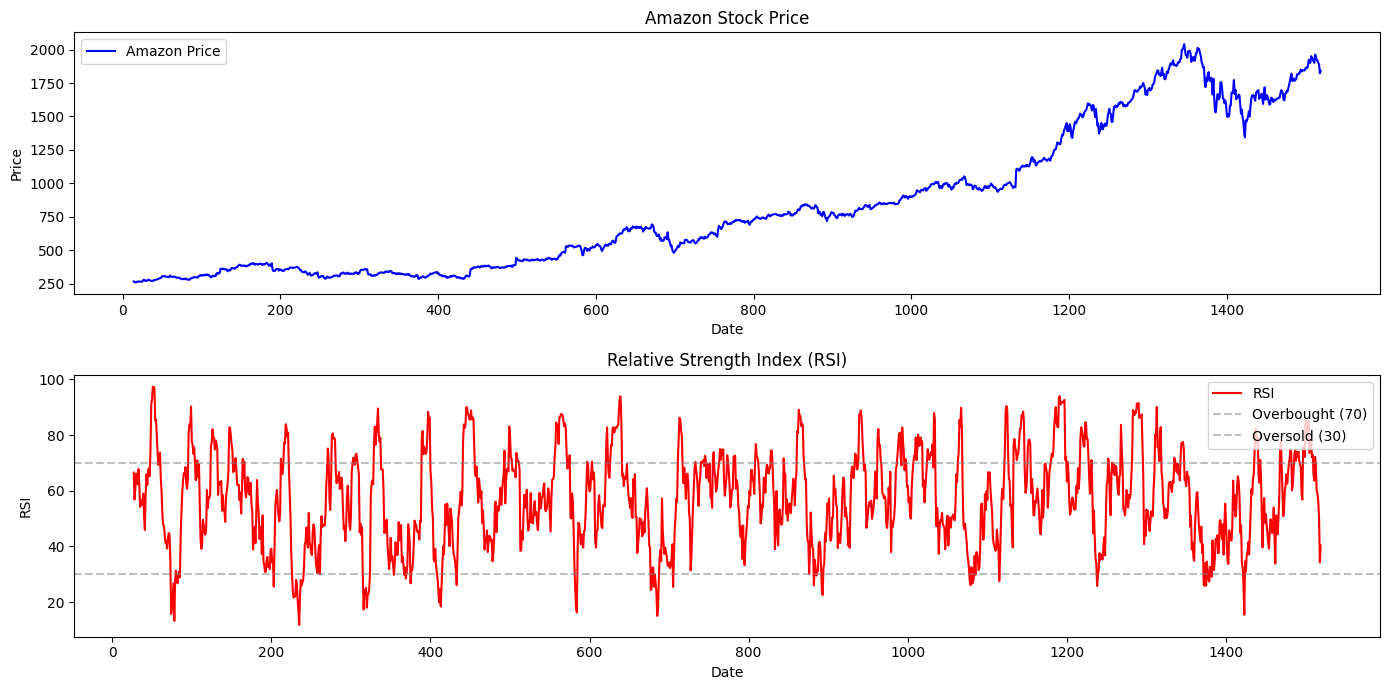

In [36]:
plt.figure(figsize=(14, 7))

# Plot the stock price
plt.subplot(2, 1, 1)
plt.plot(data['amzn'], label='Amazon Price', color='blue')
plt.title('Amazon Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

# Plot the RSI
plt.subplot(2, 1, 2)
plt.plot(data['RSI'], label='RSI', color='red')
plt.axhline(70, linestyle='--', alpha=0.5, color='grey', label='Overbought (70)')  # Overbought line
plt.axhline(30, linestyle='--', alpha=0.5, color='grey', label='Oversold (30)')  # Oversold line
plt.title('Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
# Identify overbought and oversold periods
overbought_amzn = data[data['RSI'] > 70]
oversold_amzn = data[data['RSI'] < 30]

print("Overbought Periods for AMZN:")
print(overbought_amzn[['amzn', 'RSI']])

print("\nOversold Periods for AMZN:")
print(oversold_amzn[['amzn', 'RSI']])


Overbought Periods for AMZN:
             amzn        RSI
48     292.329987  74.172560
49     299.660004  91.071336
50     307.549988  93.027898
51     306.570007  97.365650
52     306.869995  97.281131
...           ...        ...
1506  1902.250000  74.487598
1507  1950.630005  78.304963
1508  1938.430054  72.159153
1509  1926.520020  72.929128
1512  1962.459961  72.166915

[353 rows x 2 columns]

Oversold Periods for AMZN:
             amzn        RSI
74     286.470001  15.745752
75     284.820007  17.777156
76     285.570007  22.008029
77     287.089996  26.767529
78     284.570007  13.261045
...           ...        ...
1378  1770.719971  27.956185
1379  1764.030029  27.420654
1382  1664.199951  29.134467
1422  1377.449951  26.615204
1423  1343.959961  15.448257

[79 rows x 2 columns]


Feature Engineering for Modeling
Use the RSI and other features you've calculated (like moving averages) to create a DataFrame for regression analysis. If you're predicting the next day's price, prepare your features and target variable.

In [38]:
# Create a target variable
data['Target'] = data['amzn'].shift(-1)  # Next day's price

# Select features including the RSI
features = ['amzn', 'SMA_7_DPZ', 'SMA_14_DPZ', 'EMA_7_DPZ', 'RSI']
data_model_amzn = data[features + ['Target']].dropna()  # Drop rows with NaN values

print(data_model_amzn.head())


          amzn  SMA_7_DPZ  SMA_14_DPZ  EMA_7_DPZ        RSI      Target
27  281.070007  55.974404   55.439045  56.065874  66.513405  274.779999
28  274.779999  56.045339   55.629766  56.055722  56.842358  271.670013
29  271.670013  56.033217   55.831826  56.008155  60.761076  275.790009
30  275.790009  56.038759   55.899510  56.111135  66.106393  273.989990
31  273.989990  56.231483   55.971111  56.087315  63.559871  278.059998
